# 6. Live Tutorial 1: From Lab Notebook to Queryable Database — SQL and NoSQL in Practice

Notebook 3 introduced the *concepts* — rows vs. documents, a relational
schema, a document store, and the trade-offs between them — using a
deliberately small, five-batch dataset so the mechanics stayed visible.
Today's session is the payoff: a **live investigation**, using both
database styles at once, on a dataset that is actually big enough to need
a database in the first place — built end-to-end with the tools from
Part I (`numpy` for generating the data, `pandas` together with
`sqlite3`/`mongomock` for storing and querying it, `matplotlib`/`seaborn`
and `plotly` for looking at the result).

**The scenario**: since Notebook 3 left off, the lab has kept
synthesising LiFePO4 cathode batches — 40 more of them, spread across
three calcination furnaces. The process engineer has a hunch: *one of the
furnaces, overdue for calibration, might be quietly producing
lower-capacity material.* Your job today is to finish building the
database that can actually answer that question, then answer it — once in
SQL, once in MongoDB — and decide what to do about it.

Read the explanation, run the cell, look at the output, then do the
linked exercise before moving on. Section 6.6 is marked *Going further* —
useful, but not required for the core session.

**Session plan**
1. Growing the dataset — Part I's `numpy` random generator, at lab scale
2. Finishing the schema — adding the `instruments` table live (Notebook 3's Exercise 1)
3. Querying like an analyst — `JOIN`, `GROUP BY`, and the furnace mystery
4. The same investigation in MongoDB — aggregation vs. `GROUP BY`
5. When schema flexibility bites — a live demonstration
6. *Going further* — indexing and query performance at scale
7. Summary: what to do about Furnace-C

## 6.1 Recap in 60 Seconds

Notebook 3, Section 3.2 laid out the core choice: a **relational**
database (SQL) enforces one fixed set of columns per table upfront and
reunites related tables with `JOIN`; a **document** database (MongoDB)
lets every record carry its own, potentially nested shape, at the cost of
that upfront enforcement. Section 3.3–3.7 built the same five-batch
dataset both ways. Today reuses exactly those APIs
(`sqlite3`/`SQLAlchemy`, `mongomock`) — nothing new to install — just at a
scale, and with a real question, that makes the differences matter.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import mongomock
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Emit plain HTML output (not the notebook-widget MIME type), so the
# plotly figure below renders correctly in the built Jupyter Book pages.
pio.renderers.default = "notebook_connected"

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(2026)


## 6.2 Growing the Dataset

Notebook 3 hand-typed five batches as literal tuples — fine for showing
the mechanics of a schema, but nothing you would call "a database problem"
yet. A real lab generates data continuously; today we simulate the 40
batches synthesised since Notebook 3, using the same vectorised random
generation from Part I, Notebook 2 (`rng = np.random.default_rng(...)`,
`rng.uniform`, `rng.choice`) instead of typing numbers by hand.

Two synthesis methods are used, same as before (`solid-state reaction`,
`sol-gel`), each with its own temperature range and its own true
relationship between calcination temperature and capacity. Every batch's
critical `calcination_2` step is run on one of three furnaces —
**Furnace-A**, **Furnace-B**, or **Furnace-C** — chosen at random, exactly
as it would be in a real lab where whichever furnace is free gets used
next.

In [2]:
methods = ['solid-state reaction', 'sol-gel']
furnace_pool = ['Furnace-A', 'Furnace-B', 'Furnace-C']

n_new = 40
new_batches = []
for i in range(n_new):
    sample_id = f'batch_{10 + i}'
    method = rng.choice(methods, p=[0.6, 0.4])
    furnace = rng.choice(furnace_pool, p=[0.35, 0.35, 0.30])

    if method == 'solid-state reaction':
        calc2_temp = rng.uniform(700, 760)
        base_capacity = 100 + 0.08 * calc2_temp
    else:
        calc2_temp = rng.uniform(630, 690)
        base_capacity = 220 - 0.09 * calc2_temp

    # Furnace-C is overdue for calibration -- a hidden systematic offset,
    # exactly the kind of thing today's session is trying to uncover.
    calibration_penalty = 4.5 if furnace == 'Furnace-C' else 0.0
    capacity = base_capacity - calibration_penalty + rng.normal(0, 3.0)
    efficiency = np.clip(0.85 + 0.0006 * capacity + rng.normal(0, 0.008), 0.80, 0.99)

    new_batches.append({
        'sample_id': sample_id,
        'method': method,
        'furnace': furnace,
        'calc2_temp': round(float(calc2_temp), 1),
        'capacity_mAh_g': round(float(capacity), 1),
        'coulombic_efficiency': round(float(efficiency), 3),
    })

df_preview = pd.DataFrame(new_batches)
print(f'{len(df_preview)} new batches generated since Notebook 3.')
df_preview.head()


40 new batches generated since Notebook 3.


,sample_id,method,furnace,calc2_temp,capacity_mAh_g,coulombic_efficiency
0,batch_10,solid-state reaction,Furnace-B,728.0,162.4,0.953
1,batch_11,sol-gel,Furnace-C,640.6,157.0,0.942
2,batch_12,sol-gel,Furnace-C,668.2,155.1,0.944
3,batch_13,sol-gel,Furnace-B,650.3,161.1,0.936
4,batch_14,solid-state reaction,Furnace-B,739.8,158.7,0.950


**Checkpoint / Exercise A**: Change the random seed (`np.random.default_rng(2026)`
in Section 6.1) to a different integer and re-run Sections 6.1–6.2. Do the
*number* of Furnace-C batches change? Does the *hidden calibration penalty*
(4.5 mAh/g) change? Only one of the two should — which, and why?

## 6.3 Finishing the Schema: the `instruments` Table, Live

Notebook 3's Exercise 1 asked you to *design*, on paper, an `instruments`
table linked to `synthesis_steps` by a foreign key. Today we actually
build it — inside the same three-table relational schema as Notebook 3,
now with a fourth table and a new foreign-key column — and immediately
put it to work on the furnace question.

Each `synthesis_steps` row gets an `instrument_id` pointing at whichever
piece of equipment ran that step. Notice `Furnace-C`'s calibration date
below the moment the table prints — that is the process engineer's whole
reason for suspicion, in one column.

In [3]:
conn = sqlite3.connect(':memory:')
conn.execute('PRAGMA foreign_keys = ON')

conn.executescript('''
CREATE TABLE instruments (
    instrument_id          INTEGER PRIMARY KEY,
    name                   TEXT NOT NULL,
    technique              TEXT NOT NULL,
    last_calibration_date  TEXT NOT NULL
);

CREATE TABLE samples (
    sample_id   TEXT PRIMARY KEY,
    material    TEXT NOT NULL,
    method      TEXT NOT NULL,
    atmosphere  TEXT,
    creator     TEXT
);

CREATE TABLE synthesis_steps (
    step_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    sample_id     TEXT NOT NULL REFERENCES samples(sample_id),
    step_order    INTEGER NOT NULL,
    step_name     TEXT NOT NULL,
    temperature_C REAL,
    duration_h    REAL,
    instrument_id INTEGER REFERENCES instruments(instrument_id)
);

CREATE TABLE results (
    sample_id             TEXT PRIMARY KEY REFERENCES samples(sample_id),
    capacity_mAh_g        REAL NOT NULL,
    coulombic_efficiency  REAL NOT NULL
);
''')

cur = conn.cursor()
cur.executemany(
    'INSERT INTO instruments (instrument_id, name, technique, last_calibration_date) '
    'VALUES (?, ?, ?, ?)',
    [
        (1, 'Mixer-1',   'mixing',      '2025-06-01'),
        (2, 'Furnace-A', 'calcination', '2025-05-01'),
        (3, 'Furnace-B', 'calcination', '2025-04-12'),
        (4, 'Furnace-C', 'calcination', '2024-09-05'),   # overdue -- flagged by the process engineer
    ],
)
conn.commit()
print('Schema created: instruments, samples, synthesis_steps, results')
pd.read_sql_query('SELECT * FROM instruments', conn)


Schema created: instruments, samples, synthesis_steps, results


,instrument_id,name,technique,last_calibration_date
0,1,Mixer-1,mixing,2025-06-01
1,2,Furnace-A,calcination,2025-05-01
2,3,Furnace-B,calcination,2025-04-12
3,4,Furnace-C,calcination,2024-09-05


Now insert every batch — Notebook 3's original five (`batch_05`–`batch_09`,
now properly linked to instruments for the first time) plus today's 40
new ones — the same `executemany` insert pattern as Notebook 3, Section
3.3, just looped over more rows. `calcination_1` always runs on the same
dedicated preheat furnace (`Furnace-A`); `mixing` always runs on the lab's
one mixer; only `calcination_2` — the step under suspicion — varies.

In [4]:
FURNACE_ID = {'Furnace-A': 2, 'Furnace-B': 3, 'Furnace-C': 4}

original_batches = [
    # (sample_id, method, calc2_temp, furnace, capacity, efficiency)
    ('batch_05', 'solid-state reaction', 700, 'Furnace-A', 148.2, 0.91),
    ('batch_06', 'solid-state reaction', 725, 'Furnace-B', 155.9, 0.93),
    ('batch_07', 'solid-state reaction', 750, 'Furnace-A', 161.4, 0.94),
    ('batch_08', 'sol-gel',              650, 'Furnace-B', 172.1, 0.95),
    ('batch_09', 'sol-gel',              680, 'Furnace-C', 168.7, 0.92),
]

all_batches = original_batches + [
    (b['sample_id'], b['method'], b['calc2_temp'], b['furnace'],
     b['capacity_mAh_g'], b['coulombic_efficiency'])
    for b in new_batches
]

for sample_id, method, calc2_temp, furnace, capacity, efficiency in all_batches:
    cur.execute(
        'INSERT INTO samples (sample_id, material, method, atmosphere, creator) '
        'VALUES (?, ?, ?, ?, ?)',
        (sample_id, 'LiFePO4', method, 'Ar', 'A. Lindqvist'),
    )
    steps = [
        (1, 'mixing',        None,       2.0, 1),
        (2, 'calcination_1', 350,        4.0, 2),
        (3, 'calcination_2', calc2_temp, 6.0, FURNACE_ID[furnace]),
    ]
    cur.executemany(
        'INSERT INTO synthesis_steps '
        '(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) '
        'VALUES (?, ?, ?, ?, ?, ?)',
        [(sample_id, *step) for step in steps],
    )
    cur.execute(
        'INSERT INTO results (sample_id, capacity_mAh_g, coulombic_efficiency) '
        'VALUES (?, ?, ?)',
        (sample_id, capacity, efficiency),
    )
conn.commit()

n_samples = cur.execute('SELECT COUNT(*) FROM samples').fetchone()[0]
n_steps   = cur.execute('SELECT COUNT(*) FROM synthesis_steps').fetchone()[0]
print(f'{n_samples} samples, {n_steps} synthesis steps, all now linked to instruments.')


45 samples, 135 synthesis steps, all now linked to instruments.


**Checkpoint / Exercise B**: Write a `JOIN` between `synthesis_steps` and
`instruments` that lists every `calcination_2` step alongside the furnace
that ran it, for `batch_05`–`batch_09` only (`WHERE sample_id IN (...)`).
This is exactly the query Notebook 3's Exercise 1 asked for — you can now
actually run it.

## 6.4 Querying Like an Analyst: the Furnace Mystery

Time to investigate. A `JOIN` across all four tables reunites each
sample with its `calcination_2` furnace and its measured capacity — the
same `JOIN` pattern as Notebook 3, Section 3.4, just spanning one more
table. Rather than a `GROUP BY` in SQL itself, we pull the *unaggregated*
per-batch rows into a DataFrame and use `pandas`' `.groupby()` (Part I,
Notebook 3) to summarise — the two-step workflow ("filter and join in SQL,
aggregate and plot in pandas") most real analyses actually use, because it
keeps the raw rows available for plotting afterwards too.

In [5]:
df_furnace = pd.read_sql_query('''
    SELECT s.sample_id, s.method, i.name AS furnace,
           st.temperature_C AS calc2_temp, r.capacity_mAh_g
    FROM samples s
    JOIN synthesis_steps st ON st.sample_id = s.sample_id AND st.step_name = 'calcination_2'
    JOIN instruments i      ON i.instrument_id = st.instrument_id
    JOIN results r          ON r.sample_id = s.sample_id
''', conn)

summary = df_furnace.groupby('furnace')['capacity_mAh_g'].agg(['count', 'mean', 'std']).round(2)
summary


,count,mean,std
furnace,,,
Furnace-A,14,157.64,4.51
Furnace-B,19,160.48,4.37
Furnace-C,12,156.83,5.03


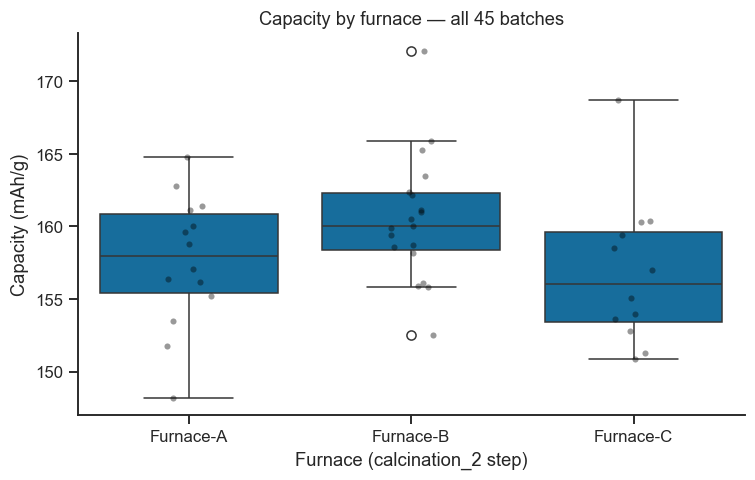

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ['Furnace-A', 'Furnace-B', 'Furnace-C']
sns.boxplot(data=df_furnace, x='furnace', y='capacity_mAh_g', order=order, ax=ax)
sns.stripplot(data=df_furnace, x='furnace', y='capacity_mAh_g', order=order,
              color='black', alpha=0.4, size=4, ax=ax)
ax.set_xlabel('Furnace (calcination_2 step)')
ax.set_ylabel('Capacity (mAh/g)')
ax.set_title(f'Capacity by furnace — all {len(df_furnace)} batches')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


The boxplot only shows two variables at once. To see whether the
furnace effect holds *across the calcination-temperature range too*, an
interactive `plotly` scatter (Part I, Notebook 5) is more useful here than
a static one — hover over any point below to see exactly which batch it
is.

In [7]:
fig_px = px.scatter(
    df_furnace, x='calc2_temp', y='capacity_mAh_g', color='furnace',
    hover_data=['sample_id', 'method'],
    category_orders={'furnace': order},
    title='Capacity vs. calcination temperature, coloured by furnace',
    template='plotly_white',
)
fig_px.show()


**Checkpoint / Exercise C**: Redo the `summary` table above with a
*two-level* `groupby(['method', 'furnace'])` instead of just
`groupby('furnace')`. Does the Furnace-C gap hold up within *both*
synthesis methods separately, or mostly within one of them? That matters
for how confident the process engineer should be.

:::{admonition} Take-home message
:class: tip

- `JOIN` reunites the normalised tables Notebook 3 split apart; `GROUP BY`
  (or, as used here, `pandas.groupby()` on the joined result) answers
  "compare X by category" questions — the single most common shape of
  real database question.
- Furnace-C's mean capacity (156.8 mAh/g) is clearly lower than
  Furnace-B's (160.5), but only slightly below Furnace-A's (157.6) —
  a real but *modest* gap, not the dramatic split the process engineer's
  hunch might suggest. That is exactly the situation a plot alone cannot
  resolve: is 156.8 vs. 157.6 a genuine (if small) furnace effect, or just
  batch-to-batch noise with only 12–19 samples per furnace? Notebook 8
  (Hypothesis Testing, Part III) gives you the formal tool — a two-sample
  t-test or ANOVA — to actually answer that, rather than eyeballing a
  boxplot.
:::

## 6.5 The Same Investigation in MongoDB

Mirror all 45 batches into a MongoDB-style document collection — same
`mongomock` stand-in as Notebook 3, Section 3.6, same "embed the synthesis
history inside the sample" shape, now with an `instrument` field on each
step.

In [8]:
client = mongomock.MongoClient()   # pymongo.MongoClient(...) against a real server
db = client['materials_lab']
coll = db['cathode_samples']

documents = []
for sample_id, method, calc2_temp, furnace, capacity, efficiency in all_batches:
    documents.append({
        'sample_id': sample_id,
        'material': 'LiFePO4',
        'method': method,
        'atmosphere': 'Ar',
        'steps': [
            {'name': 'mixing',        'instrument': 'Mixer-1',
             'duration_h': 2.0},
            {'name': 'calcination_1', 'instrument': 'Furnace-A',
             'temperature_C': 350, 'duration_h': 4.0},
            {'name': 'calcination_2', 'instrument': furnace,
             'temperature_C': calc2_temp, 'duration_h': 6.0},
        ],
        'results': {
            'capacity_mAh_g': capacity,
            'coulombic_efficiency': efficiency,
        },
    })

coll.insert_many(documents)
print(coll.count_documents({}), 'documents inserted (5 from Notebook 3 + 40 new)')


45 documents inserted (5 from Notebook 3 + 40 new)


Grouping by furnace now needs one extra pipeline stage compared to
Notebook 3, Section 3.6: `steps` is an **array**, so `$unwind` first turns
each document's step list into one pipeline document per step, then
`$match` keeps only the `calcination_2` steps, and `$group` aggregates —
MongoDB's equivalent of the `JOIN` + `GROUP BY` above, in one call.

In [9]:
pipeline = [
    {'$unwind': '$steps'},
    {'$match': {'steps.name': 'calcination_2'}},
    {'$group': {
        '_id': '$steps.instrument',
        'n_batches': {'$sum': 1},
        'mean_capacity': {'$avg': '$results.capacity_mAh_g'},
    }},
]
df_mongo_furnace = (
    pd.DataFrame(list(coll.aggregate(pipeline)))
    .rename(columns={'_id': 'furnace'})
    .sort_values('furnace')
    .reset_index(drop=True)
)
df_mongo_furnace.round(2)


,n_batches,mean_capacity,furnace
0,14,157.64,Furnace-A
1,19,160.48,Furnace-B
2,12,156.83,Furnace-C


Same question, two completely different query languages — they had
better agree. This is exactly the kind of cross-check `numpy.allclose`
(Part I, Notebook 2) is for: comparing two floating-point results without
demanding bit-for-bit equality.

In [10]:
sql_means   = summary['mean'].sort_index()
mongo_means = df_mongo_furnace.set_index('furnace')['mean_capacity'].sort_index()

print('SQL means:  ', np.round(sql_means.values, 2))
print('Mongo means:', np.round(mongo_means.values, 2))
print('SQL and MongoDB agree:', np.allclose(sql_means.values, mongo_means.values, atol=0.01))


SQL means:   [157.64 160.48 156.83]
Mongo means: [157.64 160.48 156.83]
SQL and MongoDB agree: True


## 6.6 When Schema Flexibility Bites — Live

A rushed technician logs one more Furnace-C batch, `batch_50` — but
mistypes the step name as `'clacination_2'`. Nothing in MongoDB's document
model stops this insert; there is no fixed column list to violate.

In [11]:
sloppy_doc = {
    'sample_id': 'batch_50',
    'material': 'LiFePO4',
    'method': 'sol-gel',
    'atmosphere': 'Ar',
    'steps': [
        {'name': 'mixing',        'instrument': 'Mixer-1',   'duration_h': 2.0},
        {'name': 'calcination_1', 'instrument': 'Furnace-A', 'temperature_C': 350, 'duration_h': 4.0},
        {'name': 'clacination_2', 'instrument': 'Furnace-C', 'temperature_C': 655, 'duration_h': 6.0},  # typo!
    ],
    'results': {'capacity_mAh_g': 158.9, 'coulombic_efficiency': 0.91},
}
coll.insert_one(sloppy_doc)
print(coll.count_documents({}), 'documents now — batch_50 accepted with no error at all.')

df_after = (
    pd.DataFrame(list(coll.aggregate(pipeline)))
    .rename(columns={'_id': 'furnace'})
    .set_index('furnace')
    .sort_index()
)
print()
print('Furnace-C count before batch_50:', int(summary.loc['Furnace-C', 'count']))
print('Furnace-C count after inserting batch_50:', int(df_after.loc['Furnace-C', 'n_batches']))
print('batch_50 is genuinely in the database, but invisible to the exact-match')
print("$match: {'steps.name': 'calcination_2'} stage -- the furnace investigation")
print('silently ran on incomplete data, and nothing in MongoDB flagged it.')


46 documents now — batch_50 accepted with no error at all.

Furnace-C count before batch_50: 12
Furnace-C count after inserting batch_50: 12
batch_50 is genuinely in the database, but invisible to the exact-match
$match: {'steps.name': 'calcination_2'} stage -- the furnace investigation
silently ran on incomplete data, and nothing in MongoDB flagged it.


Is this really "SQL good, MongoDB bad"? Not quite — try the *same two
mistakes* against the relational schema and see which one SQLite actually
catches.

**Mistake 1: an invalid reference** (`instrument_id` pointing at an
instrument that doesn't exist) — this is exactly what the `FOREIGN KEY`
constraint exists to prevent, in *either* database style (a real MongoDB
schema would need equivalent application-level validation to catch it,
since `mongomock`/MongoDB have no native foreign keys at all).

In [12]:
try:
    cur.execute(
        "INSERT INTO synthesis_steps "
        "(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) "
        "VALUES ('batch_09', 4, 'calcination_2', 655, 6.0, 40)"   # instrument_id 40 doesn't exist
    )
    conn.commit()
except sqlite3.IntegrityError as e:
    print('Rejected immediately:', e)


Rejected immediately: FOREIGN KEY constraint failed


**Mistake 2: the same spelling typo as `batch_50`'s** — this one is
*not* a foreign-key problem, it's a plain text column with no constraint
saying which strings are valid.

In [13]:
cur.execute(
    "INSERT INTO synthesis_steps "
    "(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) "
    "VALUES ('batch_09', 5, 'clacination_2', 655, 6.0, 4)"
)
conn.commit()
print('Accepted without complaint -- step_name has no CHECK constraint, so plain SQLite')
print('is just as blind to this specific typo as MongoDB was.')


Accepted without complaint -- step_name has no CHECK constraint, so plain SQLite
is just as blind to this specific typo as MongoDB was.


:::{admonition} Take-home message
:class: tip

- The real lesson isn't "SQL enforces everything, MongoDB enforces
  nothing" — it's that **each database only enforces exactly what you
  told it to.** A `FOREIGN KEY` protects referential integrity (Mistake 1)
  in SQL; MongoDB has no native equivalent and needs application-level
  validation (Notebook 4's `validate_entry` function is exactly that
  pattern) to get the same guarantee.
- Neither database protects you from a free-text typo (Mistake 2) unless
  you explicitly add something to catch it — a `CHECK` constraint or a
  lookup table in SQL, a validation function before every `insert_one` in
  MongoDB. "Which database did I choose?" matters less here than "what did
  I actually tell it to enforce?"
- Exercise (Core practice, below) asks you to close exactly this gap with
  a `CHECK` constraint.
:::

## 6.7 *Going Further*: Indexing and Query Performance at Scale

Everything above ran instantly because 45 rows is nothing for a database
to search — it can just scan the whole table every time. A real lab
accumulates thousands of synthesis steps over the years; at that scale,
*how* a database finds matching rows starts to matter. Simulate that
scale directly, generating 200,000 synthetic rows the same vectorised way
as Section 6.2, and time a lookup query before and after adding an
**index** — a separate, sorted structure the database can binary-search
instead of scanning row by row — using `time.perf_counter()`, the same
timing tool Part I, Notebook 1 used for comparing implementations.

In [14]:
import time

conn2 = sqlite3.connect(':memory:')
conn2.execute(
    'CREATE TABLE big_steps (id INTEGER PRIMARY KEY, sample_id TEXT, '
    'instrument_id INTEGER, capacity_mAh_g REAL)'
)

n_big = 200_000
big_instrument_ids = rng.integers(1, 5, size=n_big)
big_capacity       = rng.normal(160, 8, size=n_big)

cur2 = conn2.cursor()
cur2.executemany(
    'INSERT INTO big_steps (sample_id, instrument_id, capacity_mAh_g) VALUES (?, ?, ?)',
    [(f'sim_{i}', int(iid), float(cap))
     for i, (iid, cap) in enumerate(zip(big_instrument_ids, big_capacity))],
)
conn2.commit()
print(f'{n_big:,} synthetic step rows inserted (simulating years of accumulated lab data).')


200,000 synthetic step rows inserted (simulating years of accumulated lab data).


In [15]:
n_repeat = 20
target = 'sim_150000'   # a single, specific row -- the realistic case: "look up this one sample"

t0 = time.perf_counter()
for _ in range(n_repeat):
    cur2.execute('SELECT capacity_mAh_g FROM big_steps WHERE sample_id = ?', (target,)).fetchone()
t_no_index = (time.perf_counter() - t0) / n_repeat

cur2.execute('CREATE INDEX idx_sample_id ON big_steps(sample_id)')

t0 = time.perf_counter()
for _ in range(n_repeat):
    cur2.execute('SELECT capacity_mAh_g FROM big_steps WHERE sample_id = ?', (target,)).fetchone()
t_with_index = (time.perf_counter() - t0) / n_repeat

print(f'Without index: {t_no_index*1e6:8.1f} µs/query  (average of {n_repeat} runs)')
print(f'With index:    {t_with_index*1e6:8.1f} µs/query  (average of {n_repeat} runs)')
print(f'Speedup:       {t_no_index/t_with_index:.1f}x')


Without index:   5924.8 µs/query  (average of 20 runs)
With index:         5.7 µs/query  (average of 20 runs)
Speedup:       1039.4x


In [16]:
plan = cur2.execute(
    "EXPLAIN QUERY PLAN SELECT capacity_mAh_g FROM big_steps WHERE sample_id = 'sim_150000'"
).fetchall()
for row in plan:
    print(row)
print()
print('SEARCH ... USING INDEX confirms SQLite used the B-tree index instead of scanning')
print('all 200,000 rows -- before CREATE INDEX, this would instead read \'SCAN big_steps\'.')


(3, 0, 62, 'SEARCH big_steps USING INDEX idx_sample_id (sample_id=?)')

SEARCH ... USING INDEX confirms SQLite used the B-tree index instead of scanning
all 200,000 rows -- before CREATE INDEX, this would instead read 'SCAN big_steps'.


:::{admonition} Take-home message
:class: tip

- Indexing trades a small amount of storage and slower *writes* for much
  faster *reads* on the indexed column — worth it for a column you filter
  on often (`sample_id` here), not worth it for columns you rarely search
  directly.
- The speedup above depends on **selectivity**: `sample_id` has 200,000
  distinct values, so an index narrows the search from "scan everything"
  to "look up one row" almost immediately. A column like `instrument_id`
  (only 4 distinct values) selects roughly a quarter of the table either
  way — indexing it would help far less. Deeper-practice Exercise 1
  (below) asks you to check this directly.
- `mongomock` is a pure-Python reference implementation with no real index
  data structures, so this benchmark cannot be reproduced with it — but a
  real MongoDB server's `db.collection.create_index()` gives the same
  benefit, and `.explain()` is Mongo's equivalent of `EXPLAIN QUERY PLAN`.
:::

## 6.8 Summary: What to Do About Furnace-C

So — is Furnace-C the culprit? Across all 45 batches, Furnace-C's mean
capacity (156.8 mAh/g) is clearly below Furnace-B's (160.5) and slightly
below Furnace-A's (157.6) — a real but modest gap, and one that survived
being computed two independent ways (SQL `JOIN`+`GROUP BY` and a MongoDB
aggregation pipeline, Section 6.4–6.5). Checkpoint C asked you to check
whether it holds within both synthesis methods separately — with only
12–19 samples per furnace, that check matters. This is **suggestive, not
proof** — Notebook 8 (Hypothesis Testing, Part III) is where you get the
formal tool to turn "looks a bit lower" into "is statistically different."
The honest recommendation today is: flag Furnace-C for recalibration
regardless (its calibration date alone justifies that), and re-run the
comparison with a proper hypothesis test once you get to Notebook 8 before
treating the gap as confirmed.

| What today added on top of Notebook 3 | Where |
|---|---|
| A realistic *scale* (45 batches, not 5) generated with Part I's `numpy` tools | 6.2 |
| The `instruments` table Notebook 3's Exercise 1 only sketched, built and linked live | 6.3 |
| A real cross-table investigation, cross-checked between SQL and MongoDB | 6.4–6.5 |
| An honest, non-partisan look at what each schema does and doesn't enforce | 6.6 |
| What changes at real-lab scale: indexing and query performance | 6.7 |

Next up, Notebook 7 takes the same "query, build a DataFrame, plot" workflow
outside your own laptop entirely, against the real, public NOMAD
repository.

---
## Exercises

*(Checkpoints A–C are inline above, at the point in the notebook where you
have the context to attempt them. The following are additional practice
beyond the core session.)*

**Core practice**

1. **Close the typo gap in SQL**: Add a `CHECK` constraint to
   `synthesis_steps.step_name` restricting it to
   `('mixing', 'calcination_1', 'calcination_2')` (SQLite supports
   `CHECK` in `CREATE TABLE`). Re-attempt the `'clacination_2'` insert from
   Section 6.6, Mistake 2 — confirm it is now rejected.

2. **Close the typo gap in MongoDB**: Write a small Python function
   `validate_step(doc)` that checks every entry in `doc['steps']` has a
   `name` in the same allowed set, and call it before `insert_one` — the
   application-level enforcement MongoDB does not give you for free
   (compare to Notebook 4's `validate_entry`). Confirm it catches
   `batch_50`'s typo.

3. **Two-level breakdown, written up**: Using Checkpoint C's
   `groupby(['method', 'furnace'])` result, write 2–3 sentences
   summarising what you would tell the process engineer: is Furnace-C's
   effect consistent across both synthesis methods, or concentrated in
   one?

**Deeper practice**

4. **Selectivity matters**: Repeat the Section 6.7 benchmark, but index
   `instrument_id` instead of `sample_id`, and time a query filtering on
   `instrument_id = 4`. Is the speedup as large as it was for `sample_id`?
   Explain the difference in terms of how many rows each query actually
   matches.

5. **From this notebook to a real, shared lab database**: Describe (2–3
   sentences each) what would need to change to run today's SQL section
   against a real, shared PostgreSQL server instead of in-memory SQLite
   (Notebook 3, Section 3.5 already showed you the one line), and what
   would need to change to run the MongoDB section against a real MongoDB
   server instead of `mongomock` (hint: only the client constructor).